# 3. Alcoa quarterly EPS (1991Q4 to 2006Q4)

**Data:** `q-aa-earn.txt` — quarterly earnings per share (EPS). Some observations are **negative**, so we **do not** apply a log transform; the series is modeled in **levels**. **Method:** SARIMA with seasonal period **4** (quarters). Models are selected by **AIC** among converged fits whose residual **Ljung–Box Q(12)** (preliminary, unadjusted) suggests whiteness; the final specification is checked with **Q(12)** using **df adjustment** for estimated AR/MA parameters. **Forecasts:** 1–4 quarters ahead from the last sample quarter. **Significance:** **α = 5%**.

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

os.environ.setdefault("MPLCONFIGDIR", os.path.join(os.getcwd(), ".matplotlib_cache"))
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.rcParams["figure.figsize"] = (10, 3)

vals = []
with open("q-aa-earn.txt") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        parts = line.split()
        vals.append(float(parts[3]))

# Align to calendar quarters starting 1991Q4 (61 quarters through 2006Q4)
idx = pd.period_range("1991Q4", periods=len(vals), freq="Q").to_timestamp(how="end")
y = pd.Series(vals, index=idx, name="eps", dtype=float)
y.index.freq = y.index.inferred_freq


**Descriptive statistics, plot, stationarity.** EPS can be negative; series and first difference; Augmented Dickey–Fuller tests.

,value
count,61.000000
mean,0.278361
var,0.037667
std,0.194081
min,-0.290000
max,0.900000


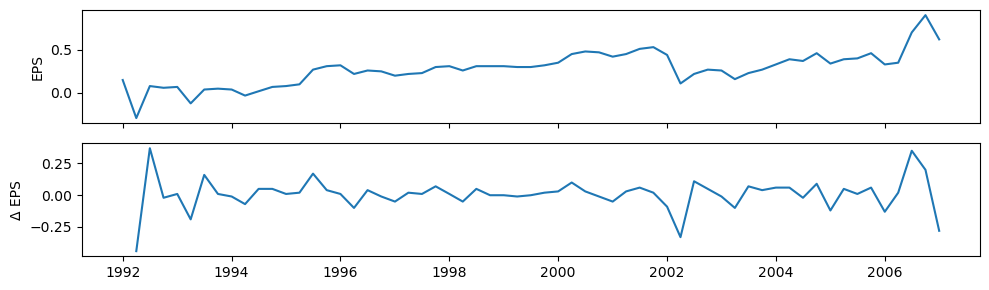

ADF level: (np.float64(-1.323846570967541), np.float64(0.6181931025603746))
ADF diff:  (np.float64(-3.550527093725335), np.float64(0.0067804064529484965))


In [2]:
display(y.agg(["count", "mean", "var", "std", "min", "max"]).to_frame("value"))

dy = y.diff().dropna()
fig, ax = plt.subplots(2, 1, sharex=True)
ax[0].plot(y.index, y.values)
ax[0].set_ylabel("EPS")
ax[1].plot(dy.index, dy.values)
ax[1].set_ylabel("Δ EPS")
plt.tight_layout()
plt.show()

print("ADF level:", adfuller(y)[:2])
print("ADF diff: ", adfuller(dy)[:2])


**Identification.** ACF/PACF of ΔEPS; Ljung–Box **Q(12)** on ΔEPS **without df adjustment** (exploratory).

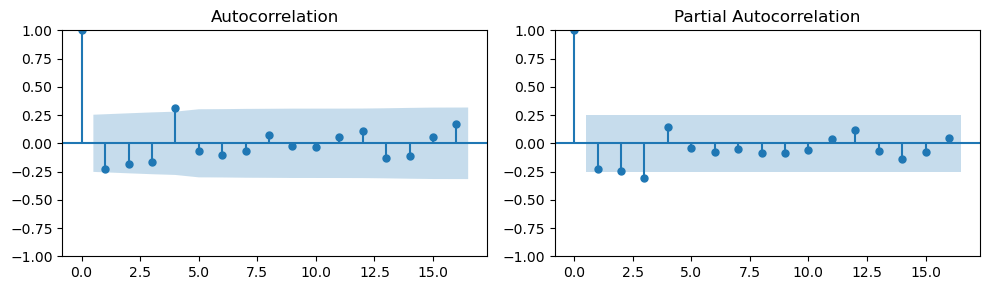

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
plot_acf(dy, lags=16, ax=axes[0])
plot_pacf(dy, lags=16, ax=axes[1], method="ywm")
plt.tight_layout()
plt.show()

print("Ljung–Box Q(12) on ΔEPS (no df adjustment):")
print(acorr_ljungbox(dy, lags=[12], return_df=True))


**Model search and estimation.** Search SARIMA(p,d,q)(P,D,Q)₄ with **p+q+P+Q ≤ 6** (parsimony), **d,D ∈ {0,1}**, orders capped at 3. Among **converged** fits with **unadjusted** residual Q(12) p-value > 0.05, pick **minimum AIC**; refit that specification.

In [4]:
cand = []
for d, D in product([0, 1], repeat=2):
    for p, q, P, Q in product(range(0, 4), repeat=4):
        if p + q + P + Q == 0 or p + q + P + Q > 6:
            continue
        try:
            res = ARIMA(
                y, order=(p, d, q), seasonal_order=(P, D, Q, 4), trend="n"
            ).fit()
            if not res.mle_retvals.get("converged", True):
                continue
            lb = acorr_ljungbox(res.resid.dropna(), lags=[12], return_df=True)
            pv = float(lb["lb_pvalue"].iloc[0])
            cand.append(
                {
                    "order": (p, d, q),
                    "seasonal_order": (P, D, Q, 4),
                    "AIC": res.aic,
                    "Q12_p": pv,
                    "result": res,
                }
            )
        except Exception:
            pass

cand_df = pd.DataFrame(
    [{k: v for k, v in c.items() if k != "result"} for c in cand]
).sort_values("AIC")
accepted = [c for c in cand if c["Q12_p"] > 0.05]
accepted.sort(key=lambda x: x["AIC"])
best = accepted[0]
fit = best["result"]

print("Top candidate orders (first 10 by AIC among passing preliminary Q12):")
print(cand_df.head(10).to_string(index=False))
print("\nSelected:", best["order"], "x", best["seasonal_order"][:3], "period 4")
print(fit.summary())


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


...

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Top candidate orders (first 10 by AIC among passing preliminary Q12):
    order seasonal_order        AIC    Q12_p
(1, 1, 1)   (1, 0, 0, 4) -94.340776 0.790353
(0, 1, 3)   (1, 0, 0, 4) -94.100175 0.723522
(1, 0, 0)   (1, 0, 0, 4) -93.998171 0.576137
(1, 0, 0)   (3, 0, 0, 4) -92.926660 0.728624
(1, 1, 2)   (1, 0, 0, 4) -92.721666 0.606253
(1, 1, 1)   (3, 0, 0, 4) -92.558699 0.823812
(2, 0, 0)   (1, 0, 0, 4) -92.406995 0.312697
(1, 1, 1)   (2, 0, 0, 4) -92.390247 0.820906
(1, 0, 1)   (1, 0, 0, 4) -92.289636 0.381867
(1, 1, 3)   (1, 0, 0, 4) -92.251892 0.680949

Selected: (1, 1, 1) x (1, 0, 0) period 4
                                    SARIMAX Results                                     
Dep. Variable:                              eps   No. Observations:                   61
Model:             ARIMA(1, 1, 1)x(1, 0, [], 4)   Log Likelihood                  51.170
Date:                          Thu, 09 Apr 2026   AIC                            -94.341
Time:                                

**Diagnostic: residual Q(12).** Ljung–Box at lag 12 with **model_df** = number of estimated AR/MA parameters (excluding σ²). **Adequacy** at 5%: p-value > 0.05 ⇒ no evidence of residual autocorrelation up to lag 12.

In [5]:
resid = fit.resid.dropna()
model_df = sum(1 for n in fit.param_names if n != "sigma2")
lb12 = acorr_ljungbox(resid, lags=[12], model_df=model_df, return_df=True)
print("model_df =", model_df)
print(lb12)

pval = float(lb12["lb_pvalue"].iloc[0])
stat = float(lb12["lb_stat"].iloc[0])
print(f"\nQ(12) = {stat:.4f}, p-value = {pval:.4g}")
if pval > 0.05:
    print("At 5%: residuals are consistent with white noise (model adequate w.r.t. this test).")
else:
    print("At 5%: reject white-noise null; consider richer dynamics.")


model_df = 3
     lb_stat  lb_pvalue
12  7.932889   0.540923

Q(12) = 7.9329, p-value = 0.5409
At 5%: residuals are consistent with white noise (model adequate w.r.t. this test).


**Fitted model (symbolic).** Let \(y_t\) denote EPS. With **statsmodels** signs, a compact form is
\[
(1 - \Phi_1 B^4)(1 - \phi_1 B)(1-B) y_t = (1 + \theta_1 B) a_t,
\]
using the estimated \(\phi_1, \theta_1, \Phi_1\) below (see also `fit.params`).

In [6]:
params = fit.params
print(params)
phi1 = params.get("ar.L1", np.nan)
theta1 = params.get("ma.L1", np.nan)
Phi1 = params.get("ar.S.L4", np.nan)
sig2 = params.get("sigma2", np.nan)
print(
    f"\n(1 - ({Phi1:.6f})B^4)(1 - ({phi1:.6f})B)(1-B) y_t = (1 + ({theta1:.6f})B) a_t,   Var(a_t) = {sig2:.6f}"
)


ar.L1      0.677776
ma.L1     -0.945927
ar.S.L4    0.700557
sigma2     0.010255
dtype: float64

(1 - (0.700557)B^4)(1 - (0.677776)B)(1-B) y_t = (1 + (-0.945927)B) a_t,   Var(a_t) = 0.010255


**Forecasts (1–4 steps ahead).** Predicted EPS for the next four quarters after **2006Q4** (last in-sample point).

In [7]:
fc = fit.get_forecast(steps=4)
out = pd.DataFrame(
    {
        "forecast_eps": fc.predicted_mean,
        "lower_95": fc.conf_int().iloc[:, 0],
        "upper_95": fc.conf_int().iloc[:, 1],
    }
)
out


,forecast_eps,lower_95,upper_95
2007-03-31 23:59:59.999999999,0.569538,0.371057,0.768018
2007-06-30 23:59:59.999999999,0.771034,0.525077,1.016991
2007-09-30 23:59:59.999999999,0.881527,0.612425,1.150630
2007-12-31 23:59:59.999999999,0.665297,0.383168,0.947426


**Summary.** EPS is modeled in **levels** because of negative values. The selected specification is **SARIMA(1,1,1)(1,0,0)₄** (lowest AIC among parsimonious candidates passing a preliminary residual Q(12) screen). The **adjusted Q(12)** on residuals is not significant at 5%, so the model is **adequate** for residual autocorrelation at that horizon. Point forecasts for 2007Q1–2007Q4 are in the table above.